# 2026-05-15 fixed_N Feature EDA

선택한 `fixed_N{n}/{variant}` 데이터셋을 train/valid/test 결합 관점에서 상세 분석합니다. `SELECTED_N`, `SELECTED_VARIANT` 값을 바꾸면 다른 개별 전처리 데이터셋에 같은 분석을 적용할 수 있습니다.


## 1. 설정 & 데이터 로드

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "preprocess").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.analysis.utils import (
    analyze_single_feature,
    build_outlier_decision_table,
    classify_columns,
    compare_group_stats_by_label,
    get_high_corr_pairs,
    high_missing_columns,
    missing_summary,
    plot_boxplot_by_label,
    plot_correlation_heatmap,
    plot_histogram,
    plot_missing_heatmap,
    render_outlier_html,
    summarize_dataframe,
)

DATA_ROOT = PROJECT_ROOT / "preprocess" / "data" / "processed"
SELECTED_N = 1
SELECTED_VARIANT = "baseline"
SPLITS = ["train", "valid", "test"]
TARGET_COLUMN = "label"
KEY_COLS = ["stock_code", "year", "quarter"]

from matplotlib import font_manager, rcParams

sns.set_theme(style="whitegrid")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["AppleGothic", "NanumGothic", "Malgun Gothic"]:
    if font_name in available_fonts:
        rcParams["font.family"] = font_name
        break
rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)


In [2]:
base_dir = DATA_ROOT / f"fixed_N{SELECTED_N}" / SELECTED_VARIANT
if not base_dir.exists():
    raise FileNotFoundError(base_dir)

with open(base_dir / "meta.json", encoding="utf-8") as f:
    meta = json.load(f)

splits = {
    split: pd.read_csv(base_dir / f"{split}.csv", dtype={"stock_code": str})
    for split in SPLITS
}

df = pd.concat(
    [split_df.assign(split=split_name) for split_name, split_df in splits.items()],
    ignore_index=True,
)

print(meta.get("labeling_rule"))
print({split: frame.shape for split, frame in splits.items()})
df.head()


상폐연도 기준 정확히 1년 전 연도의 전 분기(Q1/H1/Q3/ANNUAL) label=1. H 방식이 H개월 내 여러 분기를 양성으로 보는 것과 대칭 구조. 차이는 forward-looking(H) vs backward-looking(N) 라벨링 방식.
{'train': (35493, 41), 'valid': (5050, 41), 'test': (5311, 41)}


,stock_code,year,quarter,gics_sector,총자산증가율,유동자산증가율,매출액순이익률,매출총이익률,자기자본순이익률,매출채권회전율,재고자산회전율,총자본회전율,유형자산회전율,매출원가율,부채비율,유동비율,자기자본비율,당좌비율,비유동자산장기적합률,순운전자본비율,차입금의존도,현금비율,유형자산,무형자산,무형자산상각비,유형자산상각비,감가상각비,총자본영업이익률,총자본순이익률,유보액/납입자본비율,총자본투자효율,매출액증가율,순이익증가율,영업이익증가율,credit_spread,kosdaq_return,gdp_growth_yoy,usdkrw_chg,vix_avg,cpi_yoy,label,split
0,000250,2015,ANNUAL,Health Care,6.823177,5.069563,13.534885,54.527317,11.583135,4.079641,3.385484,0.716717,2.226743,45.472683,19.405315,455.686383,83.748366,373.994587,14.386685,41.914717,2.513236,160.554580,5.930748e+10,8.566698e+09,291937762.0,3.927886e+09,4.219823e+09,11.268190,9.700686,885.357936,0.097007,8.993624,-2.580486,0.945498,0.3758,0.5704,3.6,-1.8836,17.0333,0.9205,0,train
1,000250,2016,ANNUAL,Health Care,11.317289,17.845810,10.594630,53.655640,9.130630,3.850976,3.562665,0.718495,2.544093,46.344360,19.947494,445.957420,83.369812,372.637458,14.386685,44.100766,3.402581,185.957294,5.792753e+10,1.306613e+10,398136105.0,4.959429e+09,5.357565e+09,11.875415,7.612189,971.924847,0.076122,11.593392,-12.648630,17.316005,0.4344,-7.3061,2.8,10.2344,14.0979,1.4514,0,train
2,000250,2016,H1,Health Care,5.075305,5.007422,15.156818,53.451031,3.421313,1.087265,0.953544,0.190725,0.626175,46.548969,18.352499,470.633709,84.493357,388.980165,14.871258,42.261663,2.772066,184.266222,5.897177e+10,1.039049e+10,193893783.0,2.377207e+09,2.571101e+09,3.220310,2.890783,967.237266,0.028908,11.593392,-12.648630,17.316005,0.4607,-1.9306,3.9,0.9710,15.6759,0.8406,0,train
3,000250,2016,Q1,Health Care,1.922305,2.283415,13.871178,55.017883,3.030012,1.041355,0.886248,0.182331,0.579620,44.982117,19.803800,453.354659,83.469806,375.500543,15.080977,42.002397,2.715598,168.796741,5.907689e+10,8.723761e+09,94727918.0,1.175621e+09,1.270349e+09,3.024152,2.529145,925.834409,0.025291,11.593392,-12.648630,17.316005,0.4736,0.8837,3.0,-1.5785,20.4862,0.8593,0,train
4,000250,2016,Q3,Health Care,8.159723,9.332047,14.447036,54.245709,3.178143,1.042621,0.899470,0.185302,0.625180,45.754291,18.717165,488.228025,84.233817,403.446377,13.869592,43.162982,2.305446,199.625329,5.907089e+10,1.151650e+10,293982586.0,3.636079e+09,3.930062e+09,3.159005,2.677071,990.191551,0.026771,11.593392,-12.648630,17.316005,0.4111,0.9065,3.0,-5.8728,13.2339,0.7351,0,train


## 2. 컬럼 분류 & 기본 통계

In [3]:
cols = classify_columns(df.drop(columns=["split"]))
for group, col_list in cols.items():
    print(f"\n[{group}] ({len(col_list)}개)")
    print(col_list)



[meta] (5개)
['stock_code', 'year', 'quarter', 'gics_sector', 'label']

[ratio] (28개)
['총자산증가율', '유동자산증가율', '매출액순이익률', '매출총이익률', '자기자본순이익률', '매출채권회전율', '재고자산회전율', '총자본회전율', '유형자산회전율', '매출원가율', '부채비율', '유동비율', '자기자본비율', '당좌비율', '비유동자산장기적합률', '순운전자본비율', '차입금의존도', '현금비율', '무형자산상각비', '유형자산상각비', '감가상각비', '총자본영업이익률', '총자본순이익률', '유보액/납입자본비율', '총자본투자효율', '매출액증가율', '순이익증가율', '영업이익증가율']

[raw_value] (2개)
['유형자산', '무형자산']

[macro] (6개)
['credit_spread', 'kosdaq_return', 'gdp_growth_yoy', 'usdkrw_chg', 'vix_avg', 'cpi_yoy']


In [4]:
summarize_dataframe(df.drop(columns=["split"]))

,dtype,non_null,null_count,null_pct,unique,sample
stock_code,str,45854,0,0.0,1536,000250
year,int64,45854,0,0.0,11,2015
quarter,str,45854,0,0.0,4,ANNUAL
gics_sector,str,45854,0,0.0,11,Health Care
총자산증가율,float64,45854,0,0.0,43064,6.823177
유동자산증가율,float64,45854,0,0.0,43620,5.069563
매출액순이익률,float64,45854,0,0.0,44079,13.534885
매출총이익률,float64,45854,0,0.0,42070,54.527317
자기자본순이익률,float64,45854,0,0.0,44851,11.583135
매출채권회전율,float64,45854,0,0.0,45128,4.079641


In [5]:
numeric_cols = cols["ratio"] + cols["raw_value"] + cols["macro"]
df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
총자산증가율,45854.0,6.196398e+00,1.743828e+01,-4.398493e+01,-3.577006e+01,-1.622824e+01,-2.514483e+00,2.655318e+00,1.104174e+01,5.318692e+01,5.318692e+01,5.318692e+01
유동자산증가율,45854.0,6.834671e+00,2.775075e+01,-7.674136e+01,-5.540239e+01,-3.045554e+01,-7.506877e+00,2.266005e+00,1.531015e+01,7.644198e+01,8.581689e+01,8.581689e+01
매출액순이익률,45854.0,-1.610321e+01,7.882973e+01,-5.000000e+02,-5.000000e+02,-1.198481e+02,-8.661092e+00,2.020056e+00,9.133052e+00,2.664702e+01,7.285175e+01,1.000000e+02
매출총이익률,45854.0,2.477691e+01,2.543645e+01,-3.000000e+02,-3.522259e+01,1.444430e-01,1.223873e+01,2.151642e+01,3.579237e+01,6.422307e+01,1.000000e+02,1.000000e+02
자기자본순이익률,45854.0,-3.357265e+00,3.124663e+01,-5.000000e+02,-1.045947e+02,-2.817702e+01,-2.661089e+00,8.406398e-01,3.548642e+00,1.291101e+01,2.754725e+01,1.000000e+02
매출채권회전율,45854.0,4.392559e+00,1.309585e+01,0.000000e+00,1.389582e-01,4.941873e-01,1.147351e+00,1.874768e+00,4.045883e+00,1.178234e+01,3.619267e+01,2.000000e+02
재고자산회전율,45854.0,1.009225e+01,3.203933e+01,0.000000e+00,1.233012e-01,3.035469e-01,8.458099e-01,1.719779e+00,5.041196e+00,3.833213e+01,2.000000e+02,2.000000e+02
총자본회전율,45854.0,3.310824e-01,3.737333e-01,0.000000e+00,6.566781e-03,3.493823e-02,1.143266e-01,2.014069e-01,3.934240e-01,1.091951e+00,1.744377e+00,9.052073e+00
유형자산회전율,45854.0,5.352181e+00,1.898392e+01,0.000000e+00,3.489332e-02,1.505031e-01,4.472263e-01,1.017815e+00,2.843269e+00,1.955601e+01,1.002537e+02,2.000000e+02
매출원가율,45854.0,7.639651e+01,2.587131e+01,0.000000e+00,2.025327e+01,3.774393e+01,6.494990e+01,7.867632e+01,8.797972e+01,1.005841e+02,1.492186e+02,3.000000e+02


## 3. 결측 분석

In [6]:
missing_summary(df.drop(columns=["split"]))

,dtype,null_count,null_pct
stock_code,str,0,0.0
현금비율,float64,0,0.0
무형자산,float64,0,0.0
무형자산상각비,float64,0,0.0
유형자산상각비,float64,0,0.0
감가상각비,float64,0,0.0
총자본영업이익률,float64,0,0.0
총자본순이익률,float64,0,0.0
유보액/납입자본비율,float64,0,0.0
총자본투자효율,float64,0,0.0


In [7]:
missing_by_split = []
for split_name, split_df in splits.items():
    miss = split_df.isna().mean().rename("missing_rate").reset_index().rename(columns={"index": "column"})
    miss["split"] = split_name
    missing_by_split.append(miss)

missing_by_split_df = pd.concat(missing_by_split, ignore_index=True)
missing_pivot = missing_by_split_df.pivot(index="column", columns="split", values="missing_rate")
missing_pivot.assign(max_missing=missing_pivot.max(axis=1)).sort_values("max_missing", ascending=False).head(30)


split,test,train,valid,max_missing
column,,,,
cpi_yoy,0.0,0.0,0.0,0.0
비유동자산장기적합률,0.0,0.0,0.0,0.0
순이익증가율,0.0,0.0,0.0,0.0
영업이익증가율,0.0,0.0,0.0,0.0
유동비율,0.0,0.0,0.0,0.0
유동자산증가율,0.0,0.0,0.0,0.0
유보액/납입자본비율,0.0,0.0,0.0,0.0
유형자산,0.0,0.0,0.0,0.0
유형자산상각비,0.0,0.0,0.0,0.0


결측률 30% 이상 컬럼: []


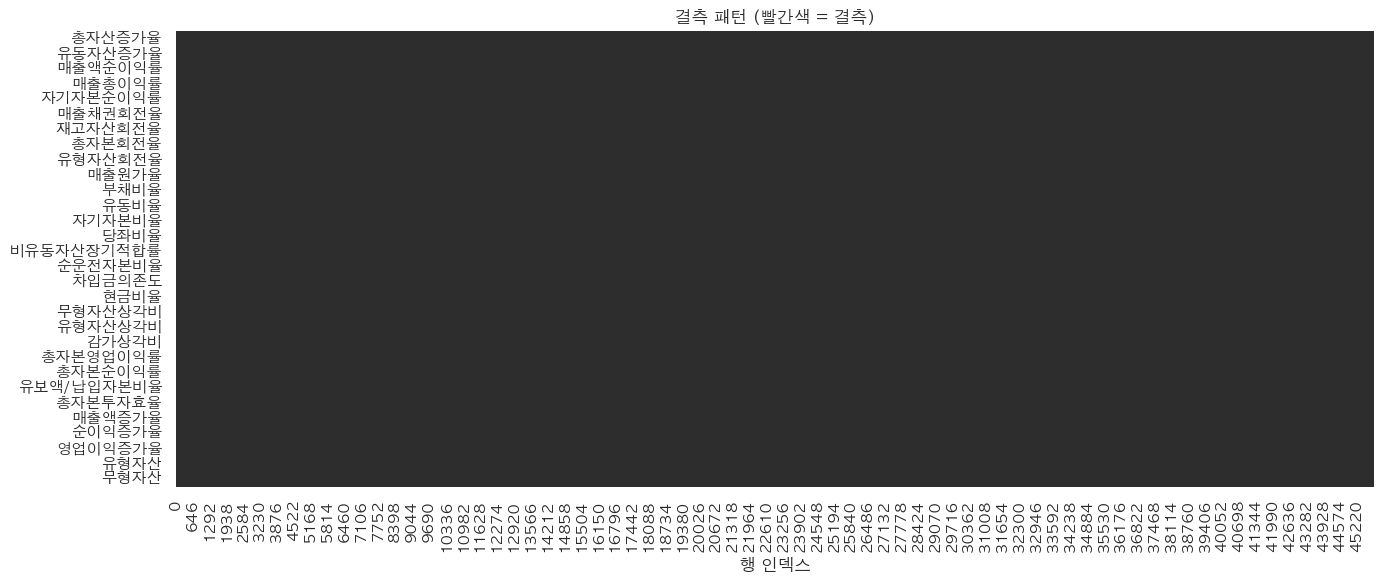

In [8]:
high_miss = high_missing_columns(df.drop(columns=["split"]), threshold=0.3)
print(f"결측률 30% 이상 컬럼: {high_miss}")
plot_missing_heatmap(df.drop(columns=["split"]))


## 4. 이상치 판정표

In [9]:
outlier_table = build_outlier_decision_table(df, numeric_cols=numeric_cols)
display(HTML(render_outlier_html(outlier_table, top_n=20)))

outlier_table[[
    "column", "count", "median", "iqr", "min", "max",
    "outlier_cnt_1_5", "outlier_ratio_1_5",
    "extreme_cnt_3_0", "extreme_ratio_3_0",
    "skew_signal", "distribution_note",
]].head(20)


컬럼,행 수,중앙값,IQR,최솟값,최댓값,이상치 수,이상치 비율,극단 수,극단 비율,왜도 신호,분포 방향
무형자산상각비,45854,0.00,0.00,-79.93M,1232.81T,11391,24.8%,11391,24.8%,iqr_zero,iqr is zero
유형자산상각비,45854,0.00,79.49M,-13.70B,1532.47T,10435,22.8%,9505,20.7%,high,right-tailed
감가상각비,45854,0.00,132.50M,-12.59B,1649.19T,10223,22.3%,9100,19.9%,high,right-tailed
비유동자산장기적합률,45854,13.84,17.77,0.00,2.00K,7523,16.4%,5950,13.0%,high,right-tailed
영업이익증가율,45854,1.37,134.23,-512.86,526.56,7361,16.1%,4347,9.5%,low,symmetric or near-symmetric
순이익증가율,45854,0.32,165.35,-621.70,637.74,7252,15.8%,4562,10.0%,low,symmetric or near-symmetric
자기자본순이익률,45854,0.84,6.21,-500.00,100.00,7097,15.5%,3798,8.3%,moderate,left-tailed
매출액순이익률,45854,2.02,17.79,-500.00,100.00,6835,14.9%,4367,9.5%,high,left-tailed
총자본투자효율,45854,0.01,0.04,-79.03,2.89,6602,14.4%,3234,7.0%,moderate,left-tailed
총자본순이익률,45854,0.49,3.72,-500.00,100.00,6604,14.4%,3241,7.1%,moderate,left-tailed


,column,count,median,iqr,min,max,outlier_cnt_1_5,outlier_ratio_1_5,extreme_cnt_3_0,extreme_ratio_3_0,skew_signal,distribution_note
0,무형자산상각비,45854,0.000000e+00,0.000000e+00,-7.992660e+07,1.232815e+15,11391,0.2484,11391,0.2484,iqr_zero,iqr is zero
1,유형자산상각비,45854,0.000000e+00,7.948853e+07,-1.369827e+10,1.532466e+15,10435,0.2276,9505,0.2073,high,right-tailed
2,감가상각비,45854,0.000000e+00,1.324951e+08,-1.259410e+10,1.649187e+15,10223,0.2229,9100,0.1985,high,right-tailed
3,비유동자산장기적합률,45854,1.384030e+01,1.777410e+01,0.000000e+00,2.000000e+03,7523,0.1641,5950,0.1298,high,right-tailed
4,영업이익증가율,45854,1.368000e+00,1.342332e+02,-5.128622e+02,5.265628e+02,7361,0.1605,4347,0.0948,low,symmetric or near-symmetric
5,순이익증가율,45854,3.159000e-01,1.653487e+02,-6.216998e+02,6.377350e+02,7252,0.1582,4562,0.0995,low,symmetric or near-symmetric
6,자기자본순이익률,45854,8.406000e-01,6.209700e+00,-5.000000e+02,1.000000e+02,7097,0.1548,3798,0.0828,moderate,left-tailed
7,매출액순이익률,45854,2.020100e+00,1.779410e+01,-5.000000e+02,1.000000e+02,6835,0.1491,4367,0.0952,high,left-tailed
8,총자본투자효율,45854,5.000000e-03,3.720000e-02,-7.903300e+01,2.891200e+00,6602,0.1440,3234,0.0705,moderate,left-tailed
9,총자본순이익률,45854,4.873000e-01,3.718200e+00,-5.000000e+02,1.000000e+02,6604,0.1440,3241,0.0707,moderate,left-tailed


## 5. 라벨 분포

In [10]:
label_by_split = df.groupby("split")[TARGET_COLUMN].value_counts().unstack(fill_value=0)
label_by_split["positive_rate"] = label_by_split.get(1, 0) / label_by_split.sum(axis=1)
label_by_split


label,0,1,positive_rate
split,,,
test,5255,56,0.010544
train,35210,283,0.007973
valid,5011,39,0.007723


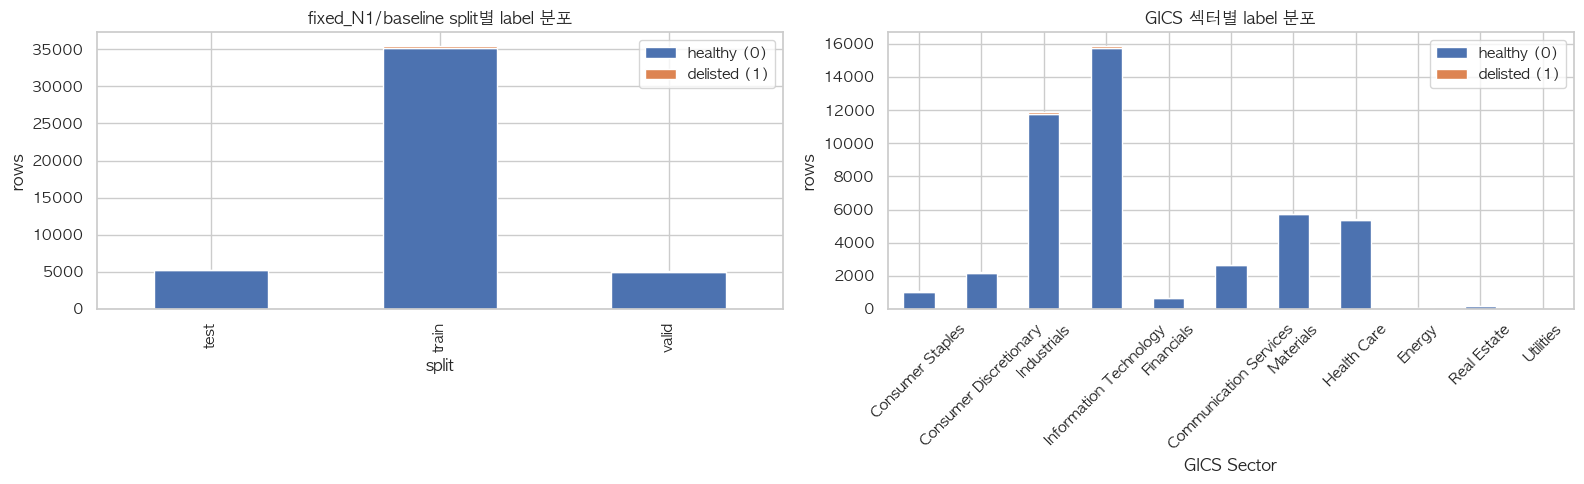

label,0,1,delisted_ratio
gics_sector,,,
Consumer Staples,1044,35,0.032437
Consumer Discretionary,2182,33,0.014898
Industrials,11764,122,0.010264
Information Technology,15773,120,0.007550
Financials,674,4,0.005900
Communication Services,2662,15,0.005603
Materials,5718,30,0.005219
Health Care,5395,19,0.003509
Energy,82,0,0.000000


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

label_by_split[[0, 1]].plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title(f"fixed_N{SELECTED_N}/{SELECTED_VARIANT} split별 label 분포")
axes[0].set_xlabel("split")
axes[0].set_ylabel("rows")
axes[0].legend(["healthy (0)", "delisted (1)"])

sector_label = df.groupby("gics_sector")[TARGET_COLUMN].value_counts().unstack(fill_value=0)
sector_label["delisted_ratio"] = sector_label.get(1, 0) / sector_label.sum(axis=1)
sector_label.sort_values("delisted_ratio", ascending=False)[[0, 1]].plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("GICS 섹터별 label 분포")
axes[1].set_xlabel("GICS Sector")
axes[1].set_ylabel("rows")
axes[1].legend(["healthy (0)", "delisted (1)"])
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

sector_label.sort_values("delisted_ratio", ascending=False)


## 6. 주요 피처 단변량 분포

In [13]:
TARGET_FEATURES = [
    "부채비율",
    "유동비율",
    "자기자본비율",
    "매출액순이익률",
    "자기자본순이익률",
    "총자본영업이익률",
    "총자본회전율",
    "차입금의존도",
    "매출총이익률",
    "현금비율",
    "credit_spread",
    "kosdaq_return",
]



  부채비율
  count: 45854
  mean: 119.07789391288097
  median: 90.86332886885906
  std: 149.62757025518582
  min: 0.0
  max: 2000.0
  q1: 36.631292223826954
  q3: 152.54342695116276
  iqr: 115.9121347273358
  skewness: 6.363946001497353
  kurtosis: 63.6170785364645


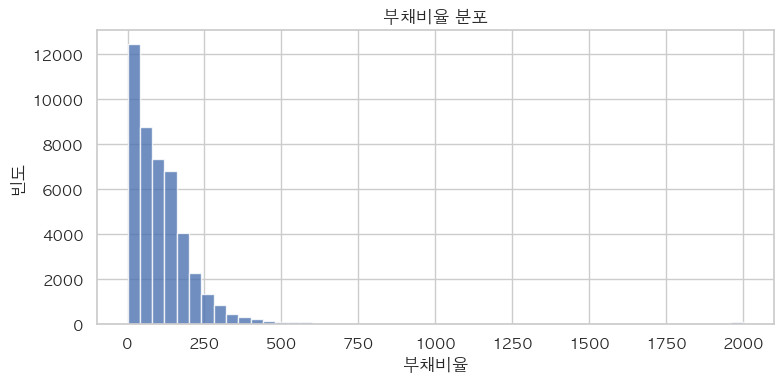

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


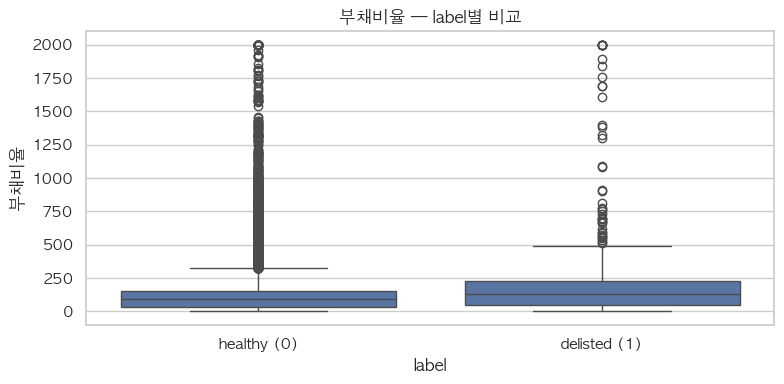


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,45476,118.080933,90.497086,145.773612,0.0,2000.0,0.0
1,378,239.019097,126.828760,381.089432,0.0,2000.0,0.0



  유동비율
  count: 45854
  mean: 335.76594280060044
  median: 193.8285775731386
  std: 385.9786530717862
  min: 0.0
  max: 2000.0
  q1: 116.75972788861634
  q3: 373.92056303870027
  iqr: 257.1608351500839
  skewness: 2.612399193640453
  kurtosis: 7.218560164459651


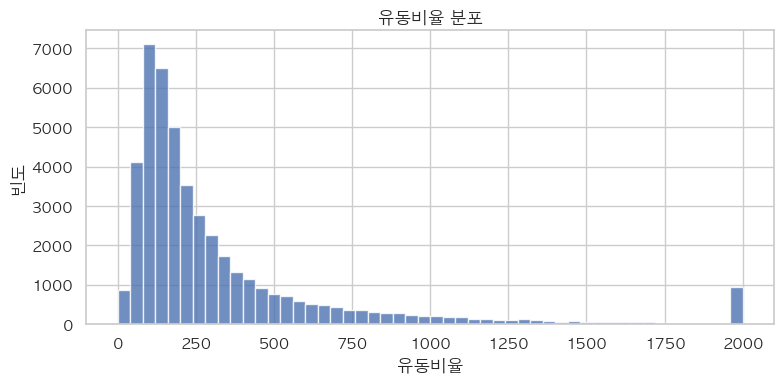

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


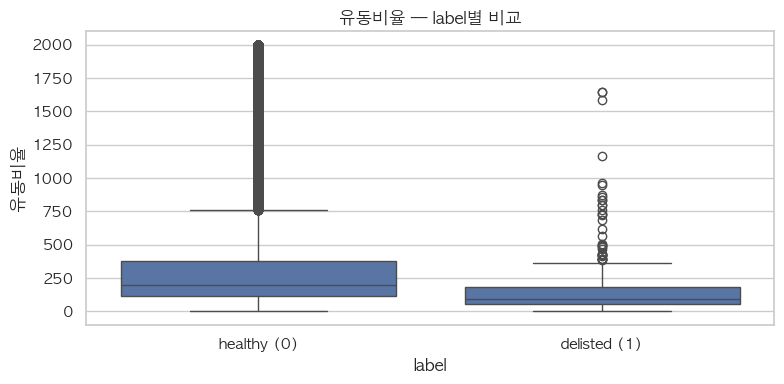


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,45476,337.196267,194.843415,386.754267,0.000000,2000.000000,0.0
1,378,163.688076,93.604510,217.126343,4.343176,1648.444233,0.0



  자기자본비율
  count: 45854
  mean: 61.472950122438505
  median: 63.04832296669322
  std: 23.71723105768842
  min: -500.0
  max: 100.0
  q1: 46.75948332721817
  q3: 78.54476008858991
  iqr: 31.78527676137174
  skewness: -4.894086786543679
  kurtosis: 97.72122944078254


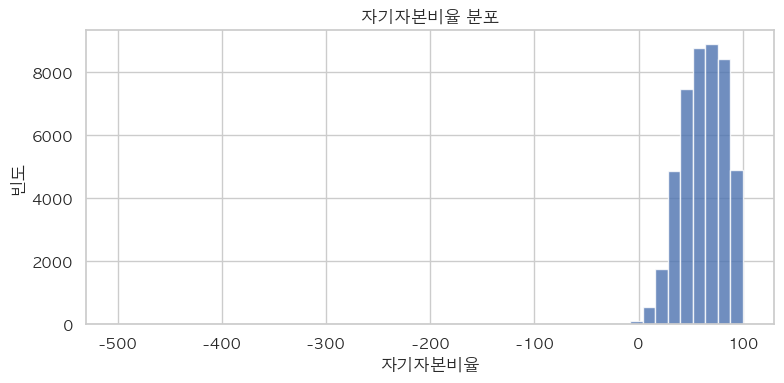

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


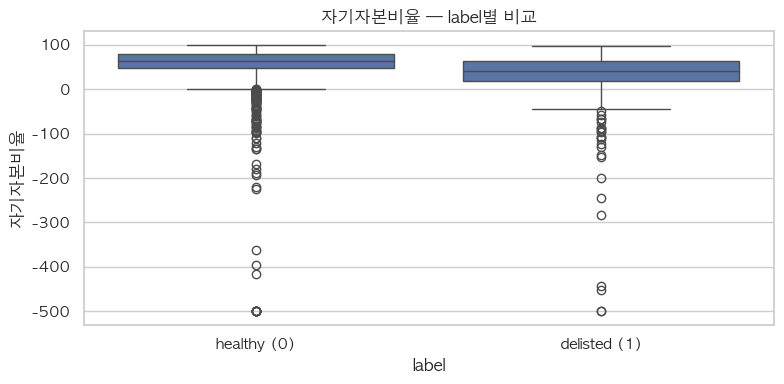


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,45476,61.736840,63.185194,22.741927,-500.0,100.000000,0.0
1,378,29.725157,40.912272,70.786029,-500.0,96.018645,0.0



  매출액순이익률
  count: 45854
  mean: -16.10321251678656
  median: 2.02005622954793
  std: 78.82972799801158
  min: -500.0
  max: 100.0
  q1: -8.661091817637287
  q3: 9.133051986406755
  iqr: 17.79414380404404
  skewness: -4.556695004026207
  kurtosis: 23.0572026006713


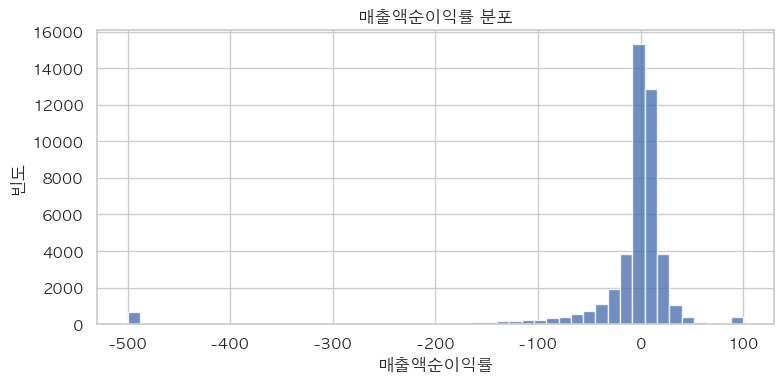

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


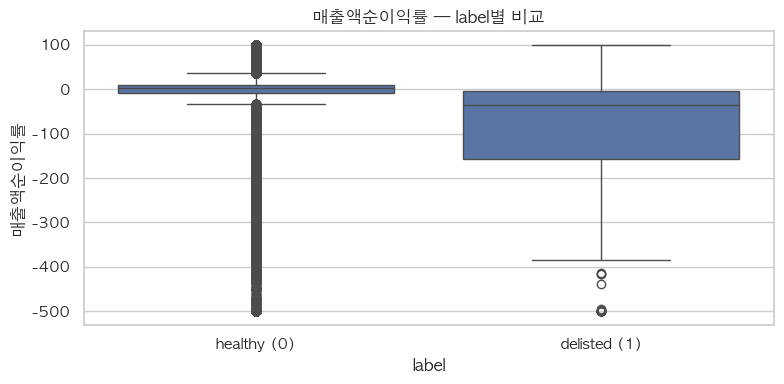


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,45476,-15.361348,2.039972,77.468732,-500.0,100.0,0.0
1,378,-105.354674,-35.579761,154.390615,-500.0,100.0,0.0



  자기자본순이익률
  count: 45854
  mean: -3.3572645194923867
  median: 0.8406397897057771
  std: 31.24663359543529
  min: -500.0
  max: 100.0
  q1: -2.6610892721349257
  q3: 3.548641830692222
  iqr: 6.209731102827147
  skewness: -10.030374782857816
  kurtosis: 137.17710774308648


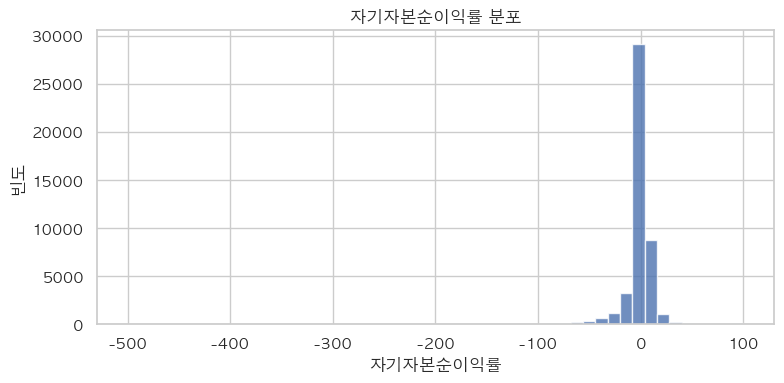

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


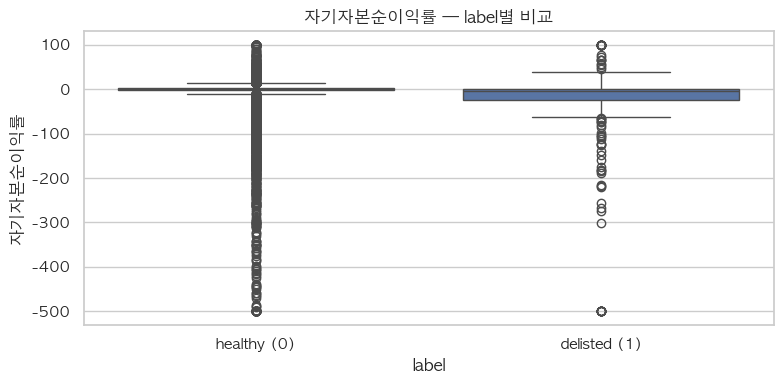


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,45476,-3.166704,0.855473,29.988817,-500.0,100.0,0.0
1,378,-26.282948,-4.798411,98.683056,-500.0,100.0,0.0



  총자본영업이익률
  count: 45854
  mean: 0.1588341459832097
  median: 0.6203127828922266
  std: 8.195003442330929
  min: -500.0
  max: 64.5085745762734
  q1: -1.1364882377754197
  q3: 2.3414699252235742
  iqr: 3.477958162998994
  skewness: -15.941624558551846
  kurtosis: 758.6462034141421


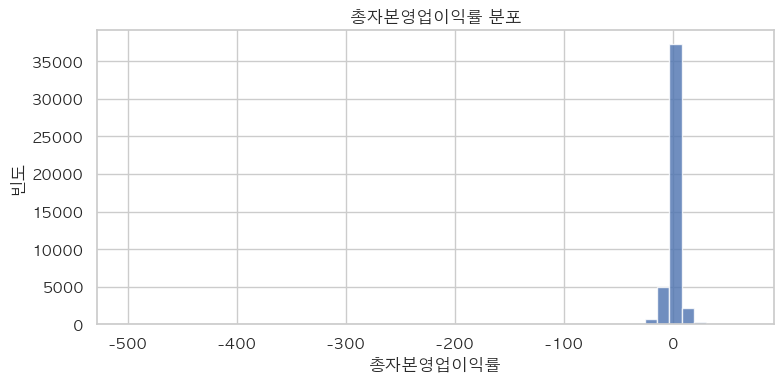

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


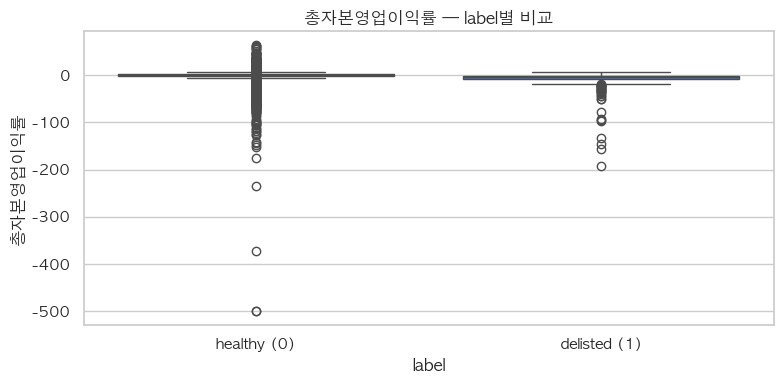


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,45476,0.229080,0.638089,7.992848,-500.000000,64.508575,0.0
1,378,-8.292194,-3.078972,19.745071,-193.000617,6.189457,0.0



  총자본회전율
  count: 45854
  mean: 0.3310824390186355
  median: 0.2014069211243822
  std: 0.3737333213436707
  min: 0.0
  max: 9.052073239367678
  q1: 0.11432663611620983
  q3: 0.3934240011774812
  iqr: 0.27909736506127136
  skewness: 3.228659243864652
  kurtosis: 21.03479598101979


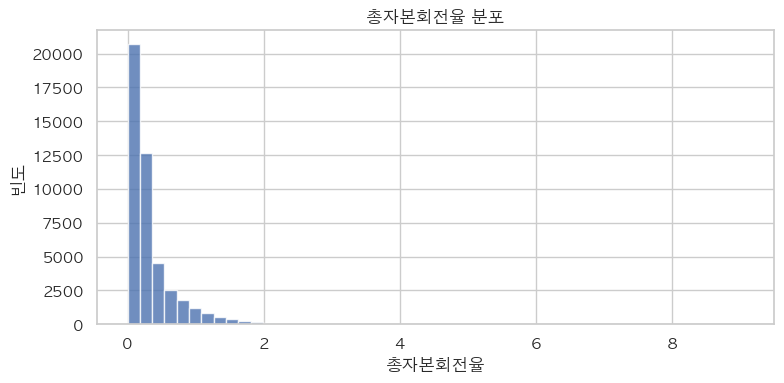

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


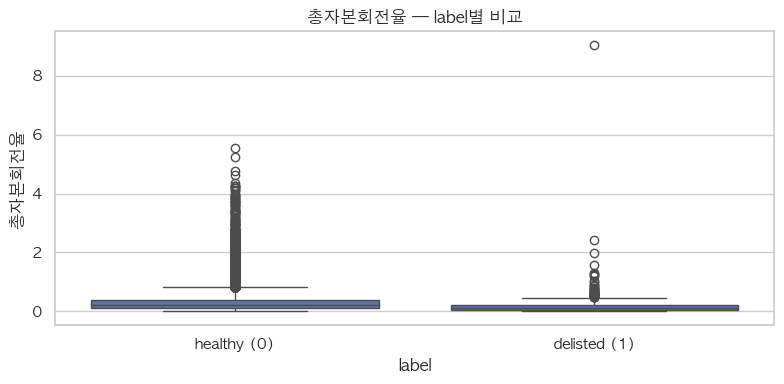


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,45476,0.332016,0.202438,0.372006,0.0,5.546385,0.0
1,378,0.218781,0.101668,0.531706,0.0,9.052073,0.0



  차입금의존도
  count: 45854
  mean: 9.41053380020302
  median: 3.6327814922581307
  std: 12.366623691272764
  min: 0.0
  max: 100.0
  q1: 0.0
  q3: 15.701189827002151
  iqr: 15.701189827002151
  skewness: 1.6003322042938914
  kurtosis: 3.0394146170519094


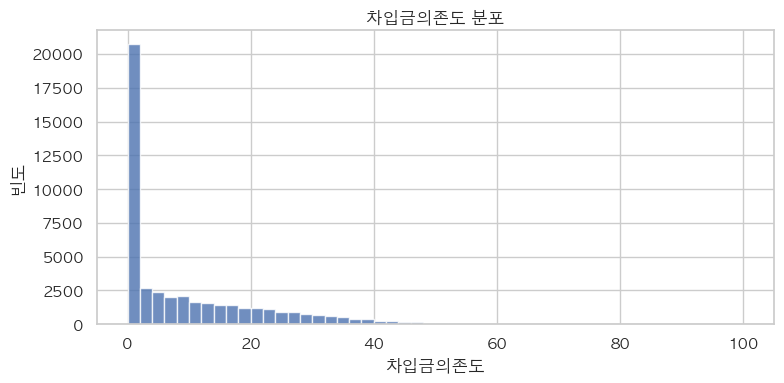

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


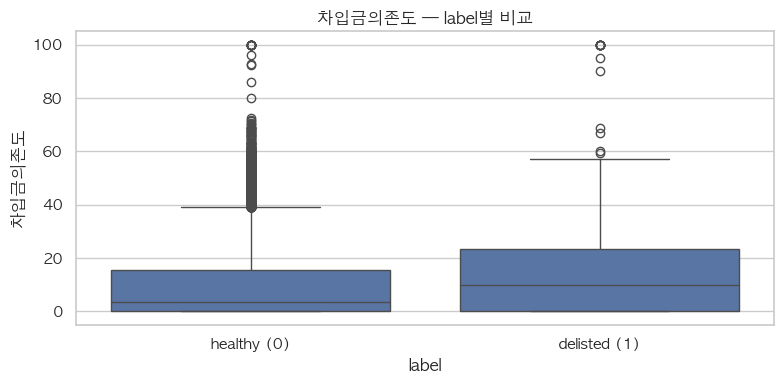


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,45476,9.354684,3.590168,12.268207,0.0,100.0,0.0
1,378,16.129638,9.839745,20.003660,0.0,100.0,0.0



  매출총이익률
  count: 45854
  mean: 24.776905459947933
  median: 21.516419902497024
  std: 25.436445847112157
  min: -300.0
  max: 100.0
  q1: 12.238734204664853
  q3: 35.79237091987114
  iqr: 23.553636715206288
  skewness: -2.761744099721842
  kurtosis: 34.751427412775854


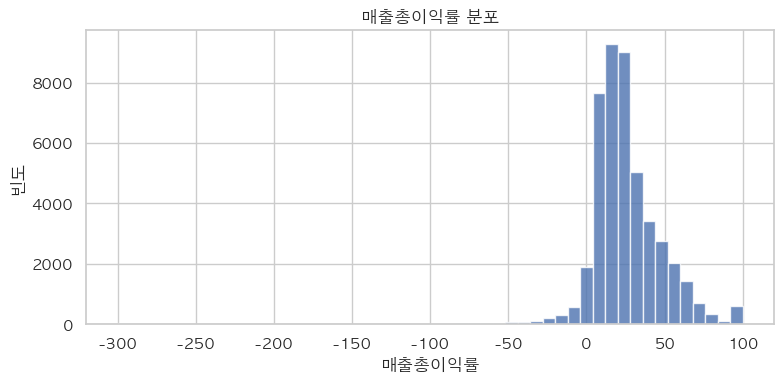

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


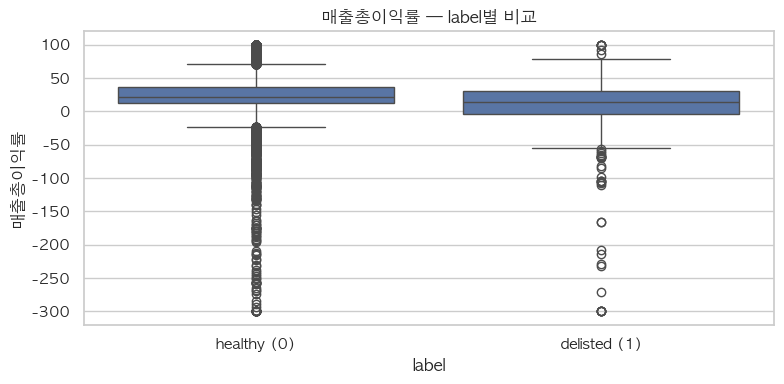


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,45476,24.954311,21.516420,24.868178,-300.0,100.0,0.0
1,378,3.433853,13.557685,60.302559,-300.0,100.0,0.0



  현금비율
  count: 45854
  mean: 104.65184927759245
  median: 40.589851054934265
  std: 229.3800850589306
  min: 0.0
  max: 2000.0
  q1: 16.07782826607099
  q3: 97.15686406175018
  iqr: 81.07903579567919
  skewness: 5.820904885983395
  kurtosis: 40.351730181119784


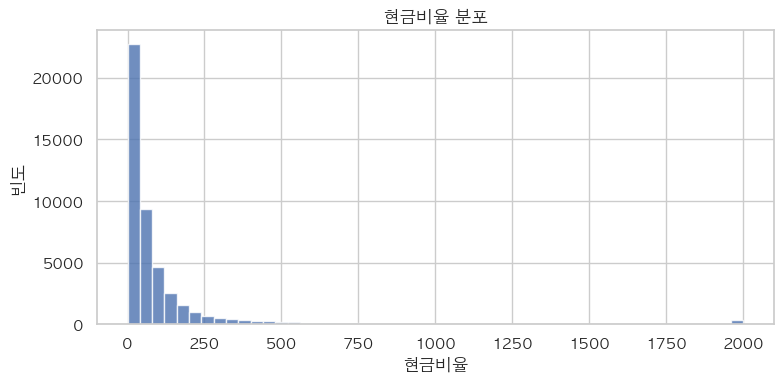

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


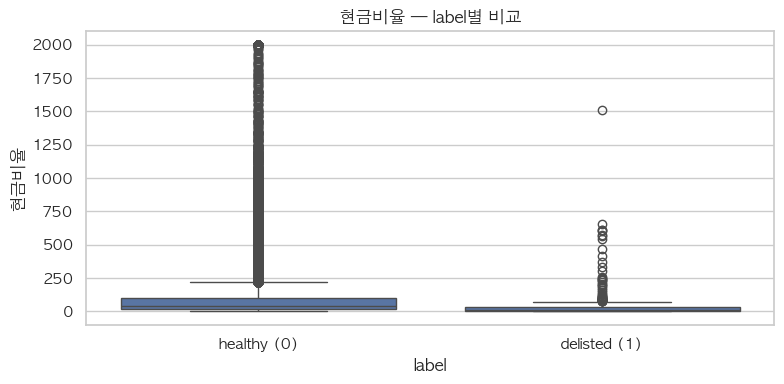


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,45476,105.150003,40.896432,229.996138,0.000000,2000.000000,0.0
1,378,44.720569,10.866319,122.422113,0.000864,1511.144307,0.0



  credit_spread
  count: 45854
  mean: 0.6747272604352946
  median: 0.5677
  std: 0.2743933320810922
  min: 0.3758
  max: 1.5024
  q1: 0.4801
  q3: 0.7777
  iqr: 0.2975999999999999
  skewness: 1.5542116739904264
  kurtosis: 1.5876481947840761


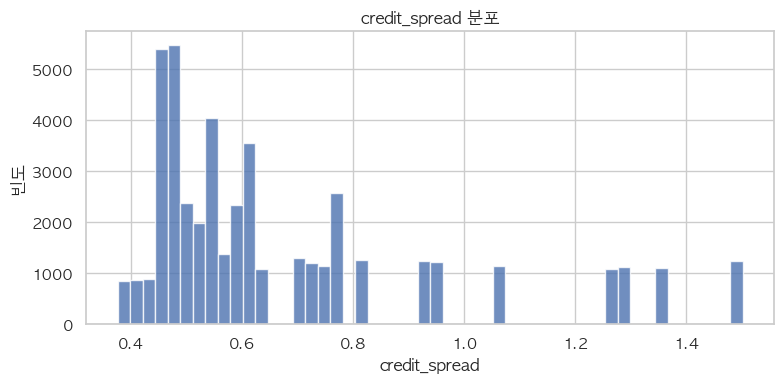

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


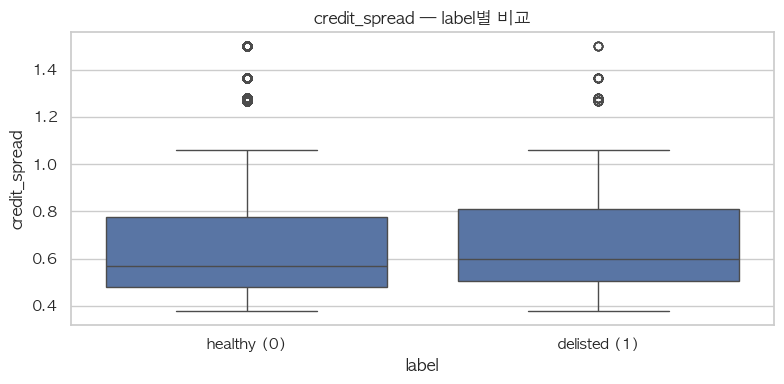


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,45476,0.674363,0.5677,0.274134,0.3758,1.5024,0.0
1,378,0.718586,0.5972,0.301150,0.3758,1.5024,0.0



  kosdaq_return
  count: 45854
  mean: 1.3599203995289397
  median: 0.5704
  std: 10.901408116444713
  min: -21.0782
  max: 29.68
  q1: -7.185
  q3: 7.7402
  iqr: 14.9252
  skewness: 0.4207908059182798
  kurtosis: 0.14818514985435893


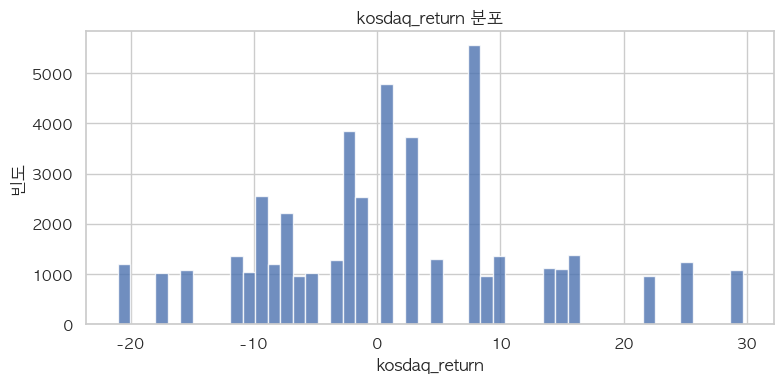

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


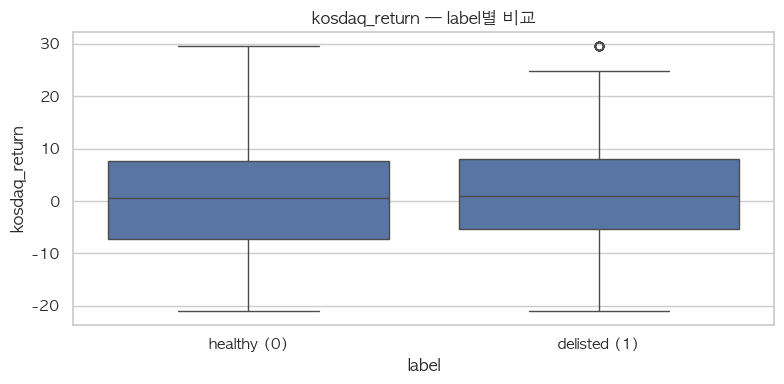


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,45476,1.348801,0.5704,10.894901,-21.0782,29.68,0.0
1,378,2.697651,0.9065,11.595417,-21.0782,29.68,0.0


In [14]:
for feat in TARGET_FEATURES:
    if feat not in df.columns:
        print(f"[SKIP] {feat} 없음")
        continue
    print(f"\n{'=' * 70}\n  {feat}\n{'=' * 70}")

    stats = analyze_single_feature(df, feat)
    for key, value in stats.items():
        print(f"  {key}: {value}")

    plot_histogram(df, feat)
    plot_boxplot_by_label(df, feat)

    print("\n[Label별 비교]")
    display(compare_group_stats_by_label(df, feat))


## 7. Label별 scatter plot

후속 EDA에서 분리 가능성을 볼 주요 피처 조합입니다. 데이터가 극단값을 많이 포함하므로 기본은 1~99 분위수 clipping 후 시각화합니다.


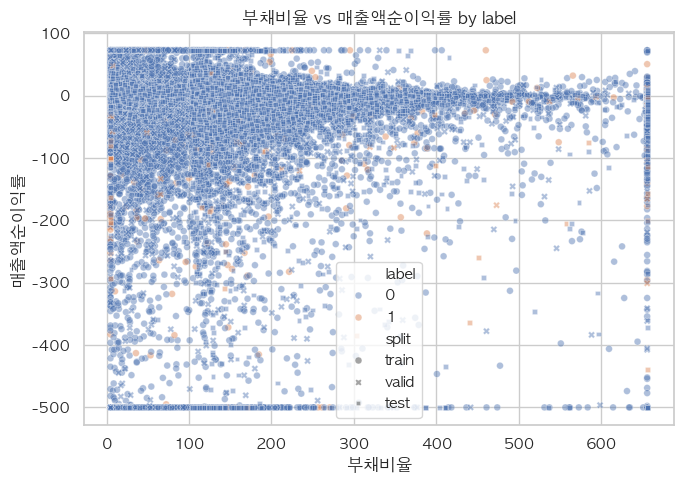

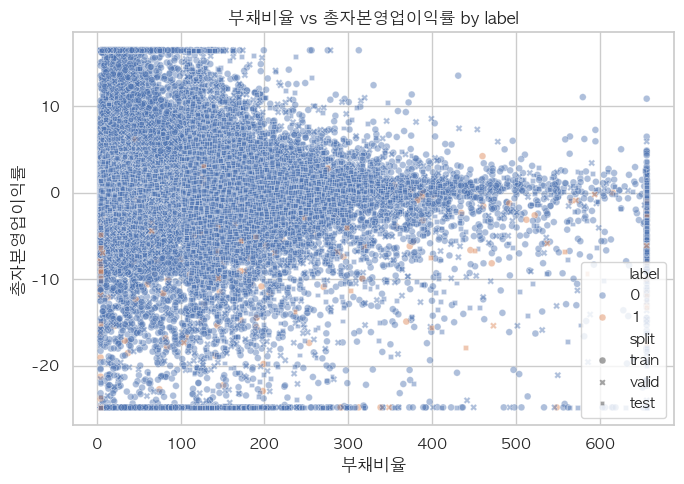

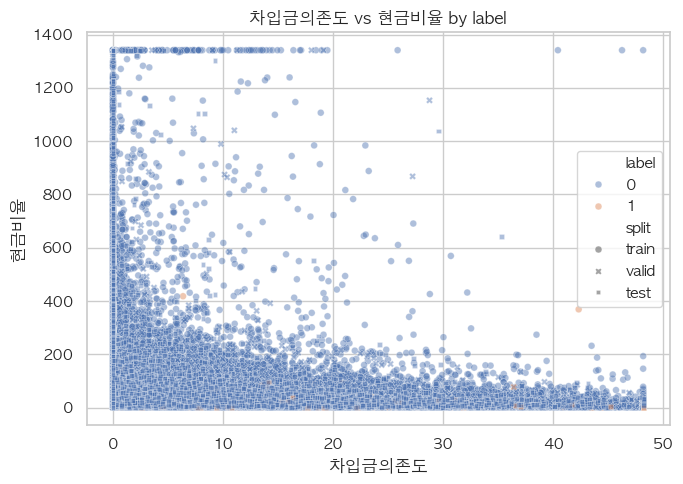

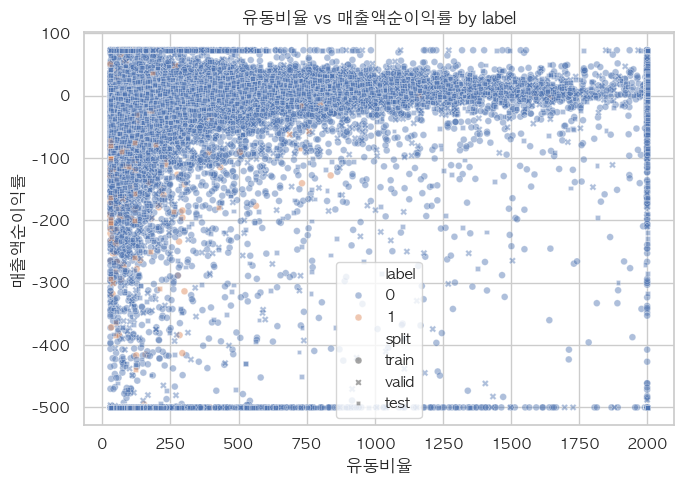

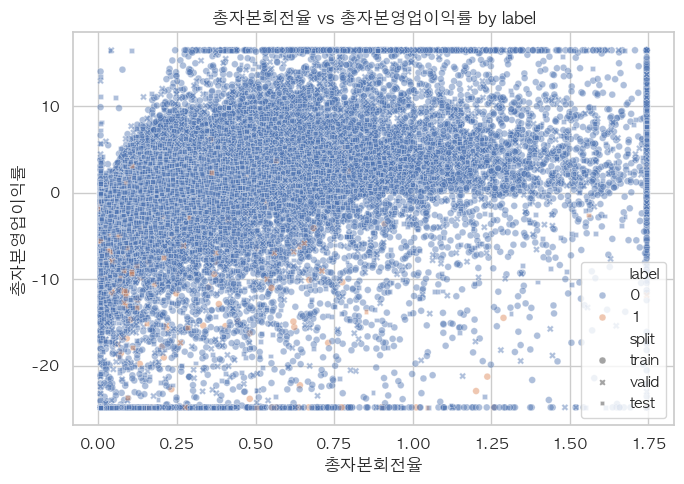

In [15]:
SCATTER_PAIRS = [
    ("부채비율", "매출액순이익률"),
    ("부채비율", "총자본영업이익률"),
    ("차입금의존도", "현금비율"),
    ("유동비율", "매출액순이익률"),
    ("총자본회전율", "총자본영업이익률"),
]


def sample_for_scatter(frame, max_negative=1200, random_state=42):
    positive = frame[frame[TARGET_COLUMN] == 1]
    negative = frame[frame[TARGET_COLUMN] == 0]
    if len(negative) > max_negative:
        negative = negative.sample(max_negative, random_state=random_state)
    return pd.concat([positive, negative], ignore_index=True)


def clipped_for_plot(frame, columns, q_low=0.01, q_high=0.99):
    out = frame.copy()
    for col in columns:
        if col not in out.columns:
            continue
        lower = out[col].quantile(q_low)
        upper = out[col].quantile(q_high)
        out[col] = out[col].clip(lower, upper)
    return out

plot_df = clipped_for_plot(df, sorted({c for pair in SCATTER_PAIRS for c in pair if c in df.columns}))

for x_col, y_col in SCATTER_PAIRS:
    if x_col not in plot_df.columns or y_col not in plot_df.columns:
        print(f"[SKIP] {x_col} x {y_col}")
        continue
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(
        data=plot_df,
        x=x_col,
        y=y_col,
        hue=TARGET_COLUMN,
        style="split",
        alpha=0.45,
        s=24,
        ax=ax,
    )
    ax.set_title(f"{x_col} vs {y_col} by label")
    plt.tight_layout()
    plt.show()


### 7.1 Label별 pairplot

주요 피처를 한 번에 묶어 label별 분리 패턴을 확인합니다. 양성은 전부 유지하고 음성은 샘플링합니다.


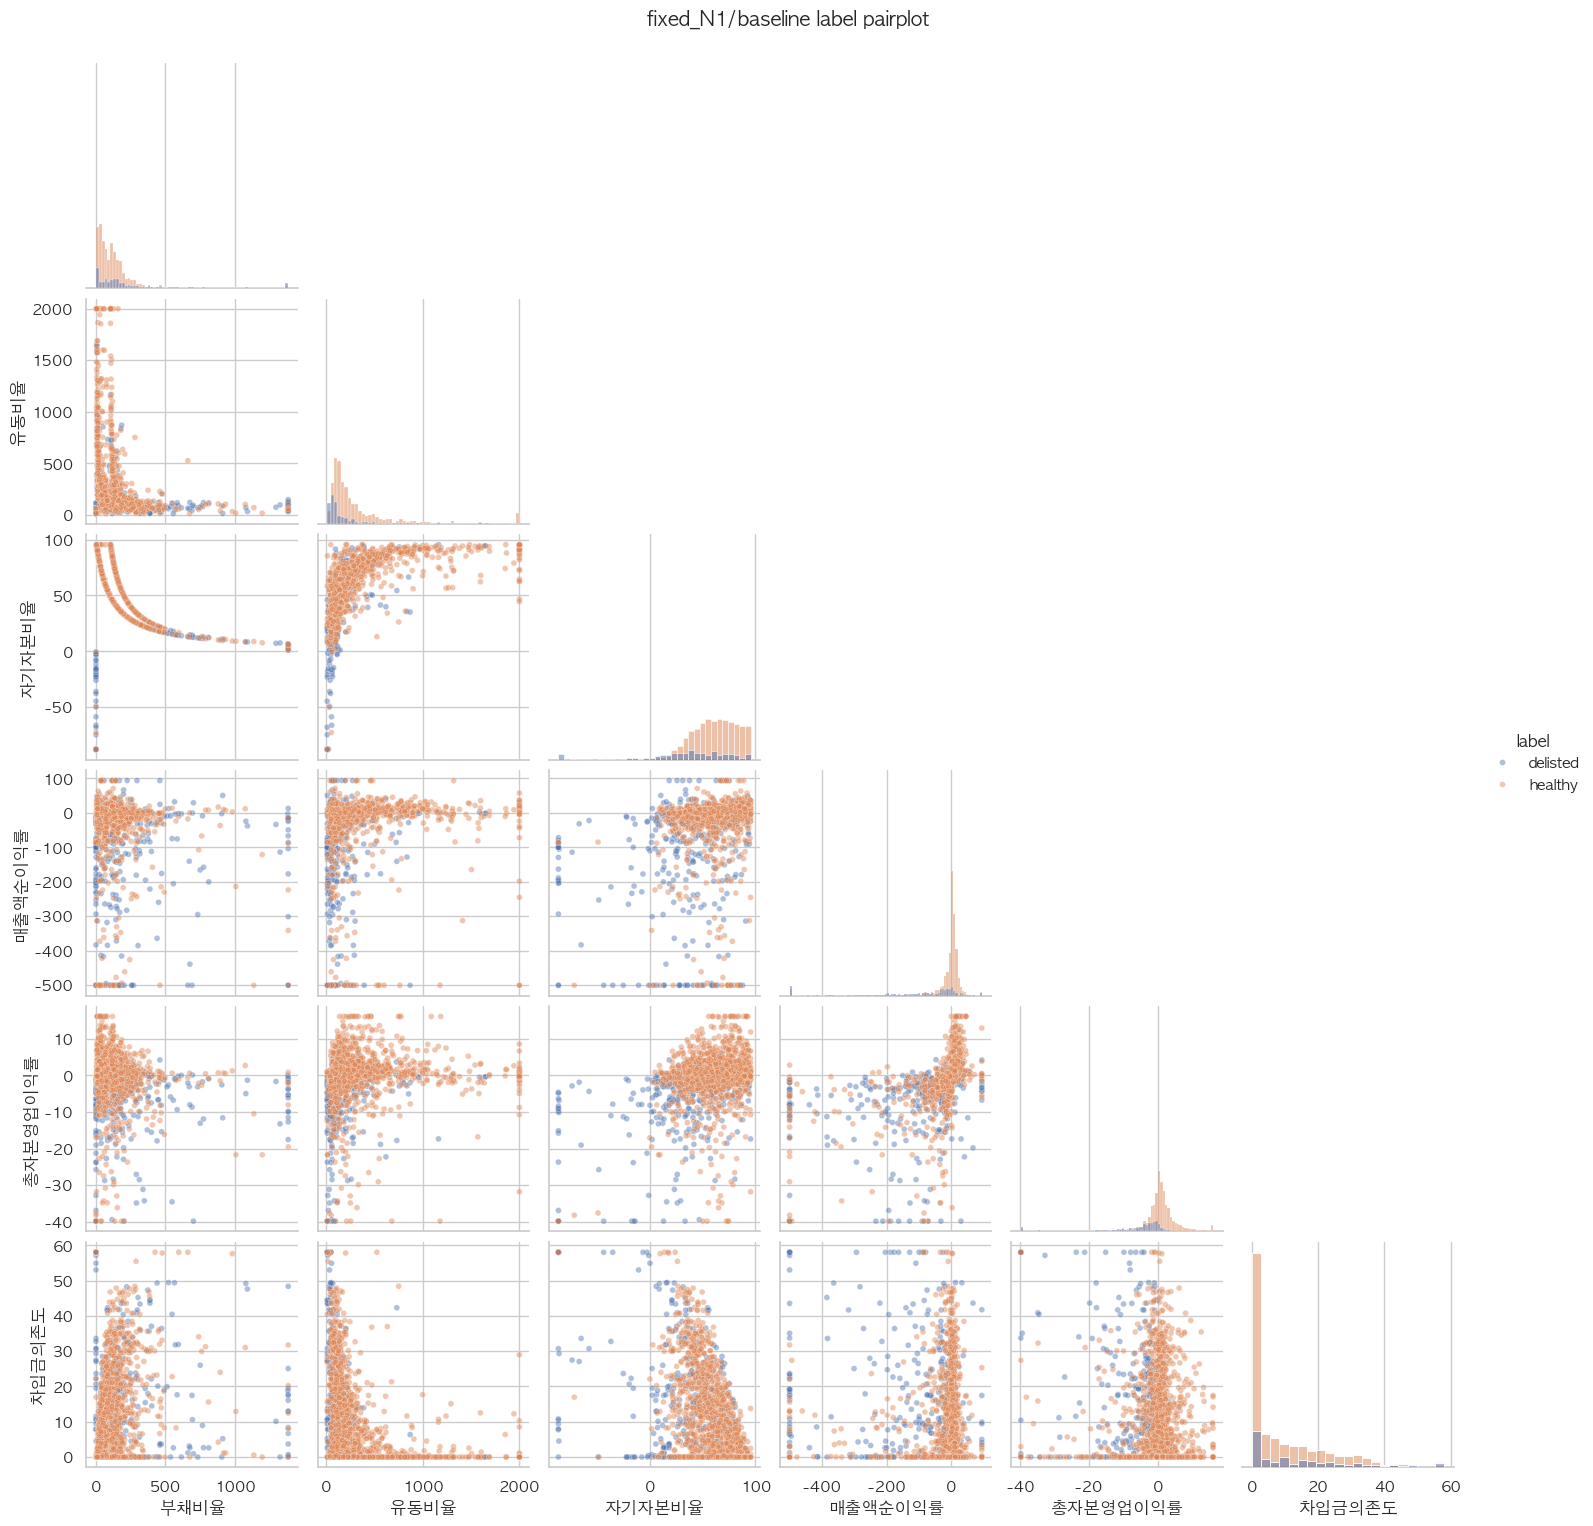

In [16]:
PAIRPLOT_FEATURES = [
    "부채비율",
    "유동비율",
    "자기자본비율",
    "매출액순이익률",
    "총자본영업이익률",
    "차입금의존도",
]
PAIRPLOT_MAX_NEGATIVE = 1500

available_pairplot_features = [c for c in PAIRPLOT_FEATURES if c in df.columns]
pairplot_cols = available_pairplot_features + [TARGET_COLUMN]

pairplot_positive = df[df[TARGET_COLUMN] == 1][pairplot_cols]
pairplot_negative = df[df[TARGET_COLUMN] == 0][pairplot_cols]
if len(pairplot_negative) > PAIRPLOT_MAX_NEGATIVE:
    pairplot_negative = pairplot_negative.sample(PAIRPLOT_MAX_NEGATIVE, random_state=42)

pairplot_df = pd.concat([pairplot_positive, pairplot_negative], ignore_index=True)
pairplot_df = clipped_for_plot(pairplot_df, available_pairplot_features)
pairplot_df[TARGET_COLUMN] = pairplot_df[TARGET_COLUMN].map({0: "healthy", 1: "delisted"})

if len(available_pairplot_features) >= 2:
    grid = sns.pairplot(
        pairplot_df,
        vars=available_pairplot_features,
        hue=TARGET_COLUMN,
        corner=True,
        diag_kind="hist",
        plot_kws={"alpha": 0.45, "s": 18},
    )
    grid.fig.suptitle(f"fixed_N{SELECTED_N}/{SELECTED_VARIANT} label pairplot", y=1.02)
    plt.show()
else:
    print("pairplot에 사용할 피처가 부족합니다.")


### 7.2 Split별 scatter 비교

같은 피처 조합이 train/valid/test에서 비슷하게 보이는지 확인합니다.


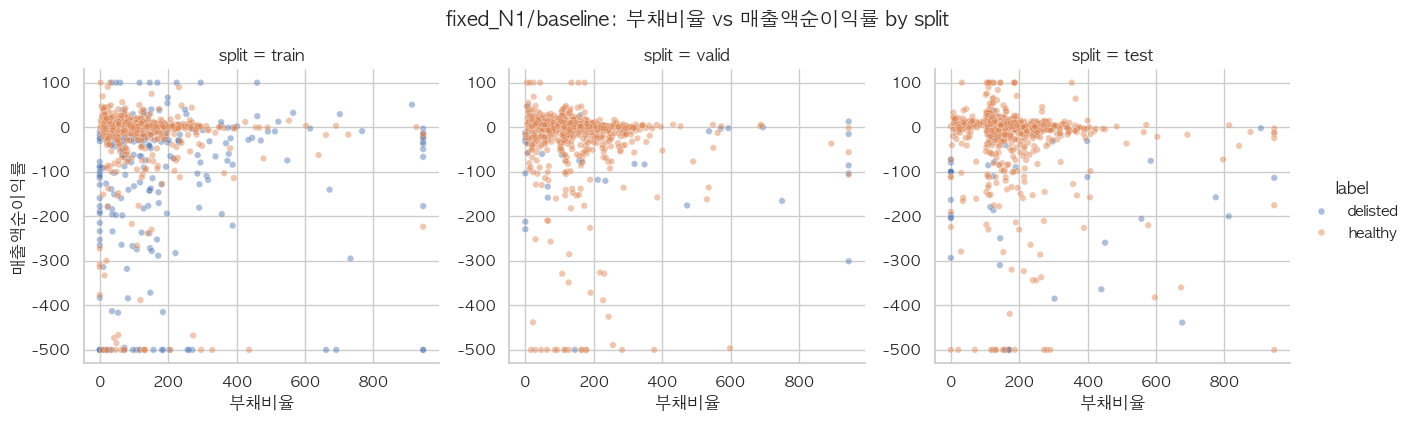

In [17]:
SPLIT_SCATTER_PAIR = ("부채비율", "매출액순이익률")
SPLIT_SCATTER_MAX_NEGATIVE = 900

x_col, y_col = SPLIT_SCATTER_PAIR
if x_col in df.columns and y_col in df.columns:
    split_scatter_frames = []
    for split_name, split_df in splits.items():
        keep_cols = [x_col, y_col, TARGET_COLUMN, "stock_code", "year", "quarter"]
        keep_cols = [c for c in keep_cols if c in split_df.columns]
        sampled = sample_for_scatter(split_df[keep_cols], max_negative=SPLIT_SCATTER_MAX_NEGATIVE)
        sampled["split"] = split_name
        split_scatter_frames.append(sampled)
    split_scatter_df = pd.concat(split_scatter_frames, ignore_index=True)
    split_scatter_df = clipped_for_plot(split_scatter_df, [x_col, y_col])
    split_scatter_df[TARGET_COLUMN] = split_scatter_df[TARGET_COLUMN].map({0: "healthy", 1: "delisted"})

    g = sns.relplot(
        data=split_scatter_df,
        x=x_col,
        y=y_col,
        hue=TARGET_COLUMN,
        col="split",
        kind="scatter",
        alpha=0.45,
        s=22,
        height=4,
        aspect=1.1,
        facet_kws={"sharex": False, "sharey": False},
    )
    g.fig.suptitle(f"fixed_N{SELECTED_N}/{SELECTED_VARIANT}: {x_col} vs {y_col} by split", y=1.05)
    plt.show()
else:
    print(f"[SKIP] {x_col} x {y_col}")


## 8. 상관관계 & 다중공선성 후보

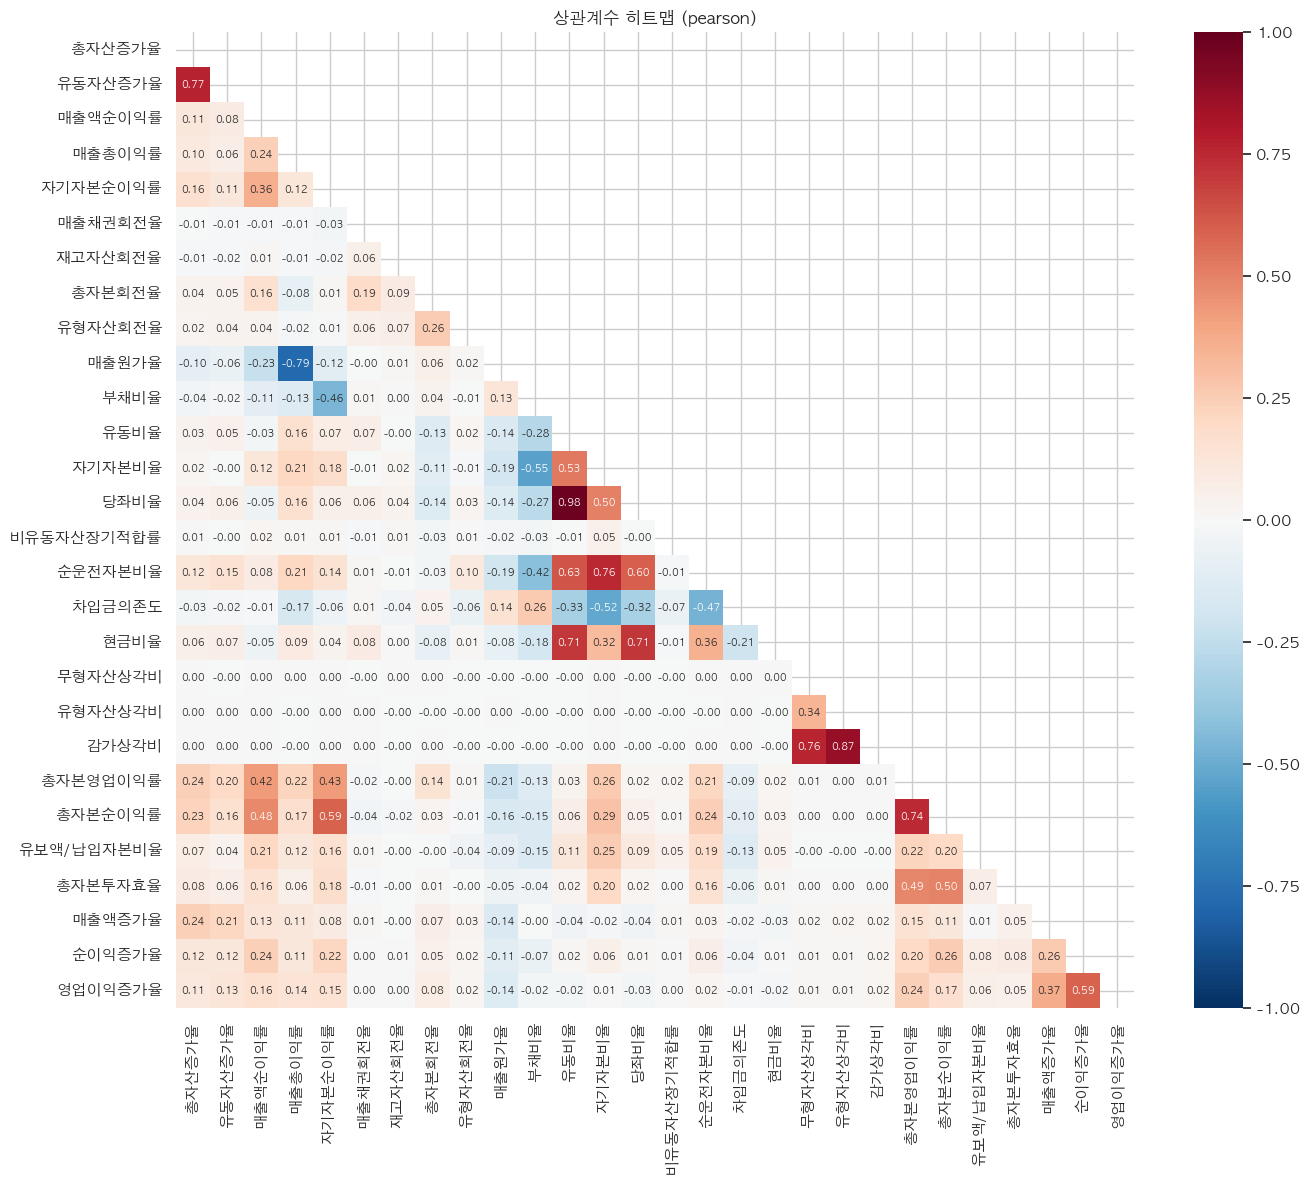

In [18]:
plot_correlation_heatmap(df.drop(columns=["split"]))

In [19]:
high_corr = get_high_corr_pairs(df.drop(columns=["split"]), threshold=0.8)
print(f"상관계수 절대값 >= 0.8 쌍: {len(high_corr)}개\n")
for col_a, col_b, corr_val in high_corr:
    print(f"  {col_a} <-> {col_b}: {corr_val}")

if high_corr:
    drop_candidates = set()
    for col_a, col_b, _ in high_corr:
        miss_a = df[col_a].isnull().mean()
        miss_b = df[col_b].isnull().mean()
        drop_candidates.add(col_a if miss_a >= miss_b else col_b)
    print(f"\n다중공선성 제거 후보 ({len(drop_candidates)}개): {sorted(drop_candidates)}")
else:
    print("다중공선성 후보 없음")


상관계수 절대값 >= 0.8 쌍: 2개

  유동비율 <-> 당좌비율: 0.9793
  유형자산상각비 <-> 감가상각비: 0.8675

다중공선성 제거 후보 (2개): ['유동비율', '유형자산상각비']


## 9. Split 누수/중복 점검

In [20]:
key_sets = {
    split_name: set(map(tuple, split_df[KEY_COLS].astype(str).to_numpy()))
    for split_name, split_df in splits.items()
}
leak_rows = []
for left, right in [("train", "valid"), ("train", "test"), ("valid", "test")]:
    overlap = key_sets[left] & key_sets[right]
    leak_rows.append({"pair": f"{left}-{right}", "overlap_keys": len(overlap)})

pd.DataFrame(leak_rows)


,pair,overlap_keys
0,train-valid,0
1,train-test,0
2,valid-test,0
